In [1]:
!pip install qiskit qiskit-aer qiskit[visualization] qiskit-ibm-runtime

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 7.7 MB/s  0:00:00
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   --------------------------- ------------ 2.4/3.5 MB 12.0 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 11.7 MB/s  0:00:00
   ---------------------------------------- 0.0/540.8 kB ? eta -:--:--
   ---------------------------------------- 540.8/540.8 kB 7.7 MB/s  0:00:00

   ----------------------------------------  0/10 [sspilib]
   ---- -----------------------------------  1/10 [PyJWT]
   ---- -----------------------------------  1/10 [PyJWT]
   -------- -------------------------------  2/10 [pycparser]
   ------------ ---------------------------  3/10 [ibm_cloud_sdk_core]
   ------------ ---------------------------  3/10 [ibm_cloud_sdk_core]
   ------------ ---------------

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
from itertools import islice

In [ ]:
# Initializing the backend
from dotenv import load_dotenv
import os

load_dotenv()
token = os.getenv("API_KEY")

QiskitRuntimeService.save_account(
    token=token
)

service = QiskitRuntimeService()

# https://quantum.cloud.ibm.com/docs/en/guides/hello-world
# https://cloud.ibm.com/iam/apikeys?bss_account=952fc7dad0544862a921fee4630e8563

qiskit_runtime_service.__init__:WARNING:2026-03-16 09:56:56,035: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [ ]:
# Fake
'''
from qiskit.primitives import StatevectorSampler
sampler = StatevectorSampler()
'''

In [4]:
# Real

from qiskit_ibm_runtime import SamplerV2 as Sampler
# Select a real backend
backend = service.least_busy(simulator=False, operational=True)
sampler = Sampler(backend)


qiskit_runtime_service.backends:WARNING:2026-03-16 09:57:28,007: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-16 09:57:31,273: Using instance: open-instance, plan: open


In [ ]:
'''
backend = service.least_busy(operational=True, simulator=False)
backend.name
'''

qiskit_runtime_service.backends:WARNING:2026-03-16 09:57:50,918: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-16 09:57:57,356: Using instance: open-instance, plan: open


'ibm_torino'

In [7]:
# Initialize quantum circuit with one qubit and one classical bit
circ = QuantumCircuit(1, 1)

# Apply Hadamard gate to qubit at the index 0
circ.h(0)

# Measure the qubit at index 0 and store in the classical bit at index 0
circ.measure(0,0)

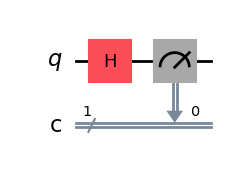

In [8]:
# Draw the quantum circuit using matplotlib
circ.draw("mpl")

In [9]:
print("Details of Classical Register: ", circ.cregs)
# Details of Classical Register:  [ClassicalRegister(1, 'c')]

print("Details of Quantum Register: ", circ.qregs)
# Details of Quantum Register:  [QuantumRegister(1, 'q')]

Details of Classical Register:  [ClassicalRegister(1, 'c')]
Details of Quantum Register:  [QuantumRegister(1, 'q')]


In [10]:
# Transpile 
circ = transpile(circ, backend)

In [27]:
# Run the simulator 640000 times to generate 1000 64-bit number
job = sampler.run([(circ,None, 64*1000)])
result = job.result()
# Extract the results from memory in a list and print them
print(result[0].data)
memory = result[0].data.c.get_bitstrings()
# print(memory)

DataBin(c=BitArray(<shape=(), num_shots=64000, num_bits=1>))


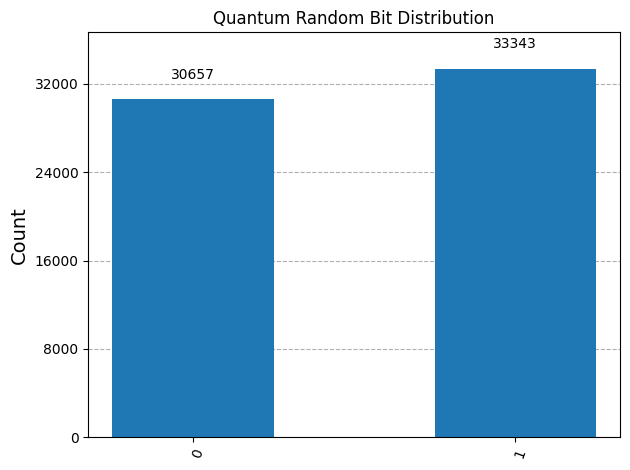

In [32]:
# Get the data of our experiment
counts = result[0].data.c.get_counts()

# Plot the data in a histogram
plot_histogram(counts, title='Quantum Random Bit Distribution')

In [28]:
a = memory  
n = 64  

it = iter(a) 
res = [str(int(''.join((islice(it, n))) , 2)) for _ in range((len(a) + n - 1) // n)]
print(len(res))

1000


In [ ]:
with open("real.txt", "w") as f:
    f.write("\n".join(res))